In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("marketing_campaign_dataset.csv")

In [5]:

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Shape: (200000, 16)

Columns: ['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date']


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [9]:
print("missing cell:")
print(df.isnull().sum())

print("\nBasic Stats:")
df.describe()

missing cell:
Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

Basic Stats:


,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


In [12]:
print(df.columns.tolist())
print("\nShape:", df.shape)
df.head(3)

['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date']

Shape: (200000, 16)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03


In [11]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64


In [13]:
# Fix Acquisition_Cost — remove '$' and ',' so we can do math on it
df['Acquisition_Cost'] = df['Acquisition_Cost'].replace('[\$,]', '', regex=True).astype(float)

In [16]:
# Fix Duration — extract just the number (30, 60 etc.)
df['Duration_Days'] = df['Duration'].str.extract('(\d+)').astype(int)

In [17]:
#fix the date 
df['Date'] = pd.to_datetime(df['Date'])

print("\nCleaned! New dtypes:")
print(df[['Acquisition_Cost', 'Duration_Days', 'Date']].dtypes)
df.head(3)


Cleaned! New dtypes:
Acquisition_Cost           float64
Duration_Days                int64
Date                datetime64[ns]
dtype: object


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Duration_Days
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,30
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,60
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,30


In [18]:
# CTR = Clicks / Impressions * 100
df['CTR'] = (df['Clicks'] / df['Impressions']) * 100

print("CTR column added!")
print(df['CTR'].describe())

CTR column added!
count    200000.000000
mean         14.040550
std          13.088122
min           1.005429
25%           5.860555
50%           9.978933
75%          16.969863
max          99.202393
Name: CTR, dtype: float64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all plots
plt.style.use('dark_background')
sns.set_palette("husl")

# Group by channel and calculate average metrics
channel_performance = df.groupby('Channel_Used').agg(
    Avg_ROI        = ('ROI', 'mean'),
    Avg_CTR        = ('CTR', 'mean'),
    Avg_Conversion = ('Conversion_Rate', 'mean'),
    Avg_CAC        = ('Acquisition_Cost', 'mean'),
    Total_Clicks   = ('Clicks', 'sum'),
    Campaign_Count = ('Campaign_ID', 'count')
).round(2).reset_index()

print(channel_performance)

  Channel_Used  Avg_ROI  Avg_CTR  Avg_Conversion   Avg_CAC  Total_Clicks  \
0        Email     5.00    14.05            0.08  12526.39      18493963   
1     Facebook     5.02    14.05            0.08  12510.90      18037947   
2   Google Ads     5.00    13.92            0.08  12528.03      18340807   
3    Instagram     4.99    14.00            0.08  12491.76      18316654   
4      Website     5.01    14.10            0.08  12487.81      18414628   
5      YouTube     4.99    14.12            0.08  12481.39      18350407   

   Campaign_Count  
0           33599  
1           32819  
2           33438  
3           33392  
4           33360  
5           33392  


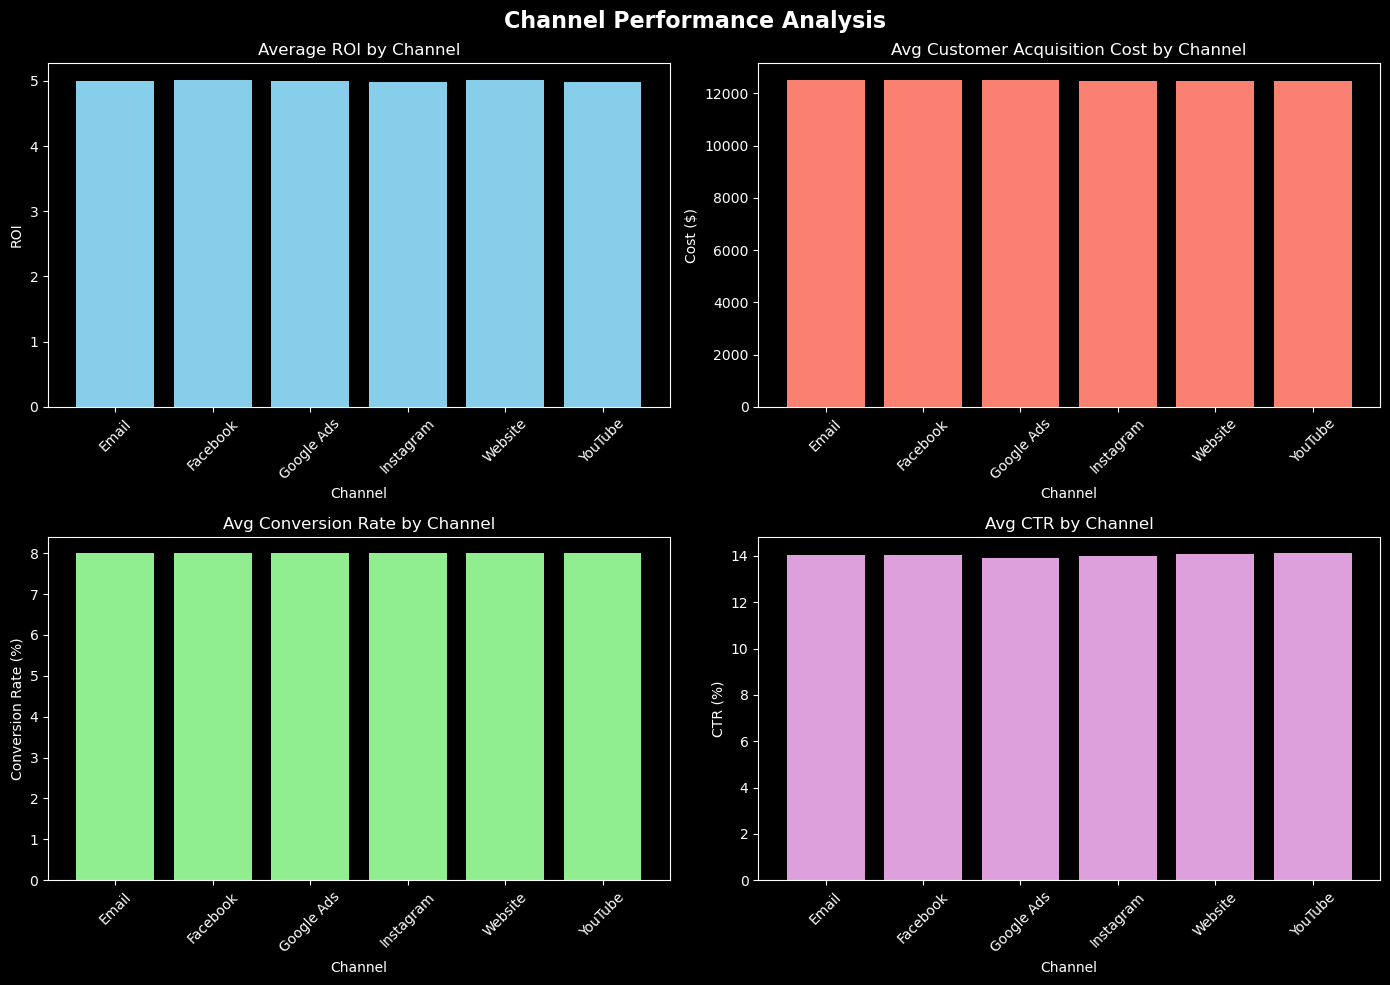

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Channel Performance Analysis', fontsize=16, fontweight='bold')

# Plot 1 — Average ROI by Channel
axes[0,0].bar(channel_performance['Channel_Used'], 
              channel_performance['Avg_ROI'], 
              color='skyblue')
axes[0,0].set_title('Average ROI by Channel')
axes[0,0].set_xlabel('Channel')
axes[0,0].set_ylabel('ROI')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2 — Average CAC by Channel
axes[0,1].bar(channel_performance['Channel_Used'], 
              channel_performance['Avg_CAC'], 
              color='salmon')
axes[0,1].set_title('Avg Customer Acquisition Cost by Channel')
axes[0,1].set_xlabel('Channel')
axes[0,1].set_ylabel('Cost ($)')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 — Conversion Rate by Channel
axes[1,0].bar(channel_performance['Channel_Used'], 
              channel_performance['Avg_Conversion']*100, 
              color='lightgreen')
axes[1,0].set_title('Avg Conversion Rate by Channel')
axes[1,0].set_xlabel('Channel')
axes[1,0].set_ylabel('Conversion Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4 — CTR by Channel
axes[1,1].bar(channel_performance['Channel_Used'], 
              channel_performance['Avg_CTR'], 
              color='plum')
axes[1,1].set_title('Avg CTR by Channel')
axes[1,1].set_xlabel('Channel')
axes[1,1].set_ylabel('CTR (%)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('channel_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Print exact numbers so we can spot differences
print(channel_performance.to_string())

  Channel_Used  Avg_ROI  Avg_CTR  Avg_Conversion   Avg_CAC  Total_Clicks  Campaign_Count
0        Email     5.00    14.05            0.08  12526.39      18493963           33599
1     Facebook     5.02    14.05            0.08  12510.90      18037947           32819
2   Google Ads     5.00    13.92            0.08  12528.03      18340807           33438
3    Instagram     4.99    14.00            0.08  12491.76      18316654           33392
4      Website     5.01    14.10            0.08  12487.81      18414628           33360
5      YouTube     4.99    14.12            0.08  12481.39      18350407           33392


  Campaign_Type  Avg_ROI  Avg_CTR  Avg_Conversion   Avg_CAC  Campaign_Count
0       Display     5.01    14.13            0.08  12508.03           39987
1         Email     4.99    13.95            0.08  12495.35           39870
2    Influencer     5.01    14.03            0.08  12507.17           40169
3        Search     5.01    13.99            0.08  12498.74           40157
4  Social Media     4.99    14.10            0.08  12512.70           39817


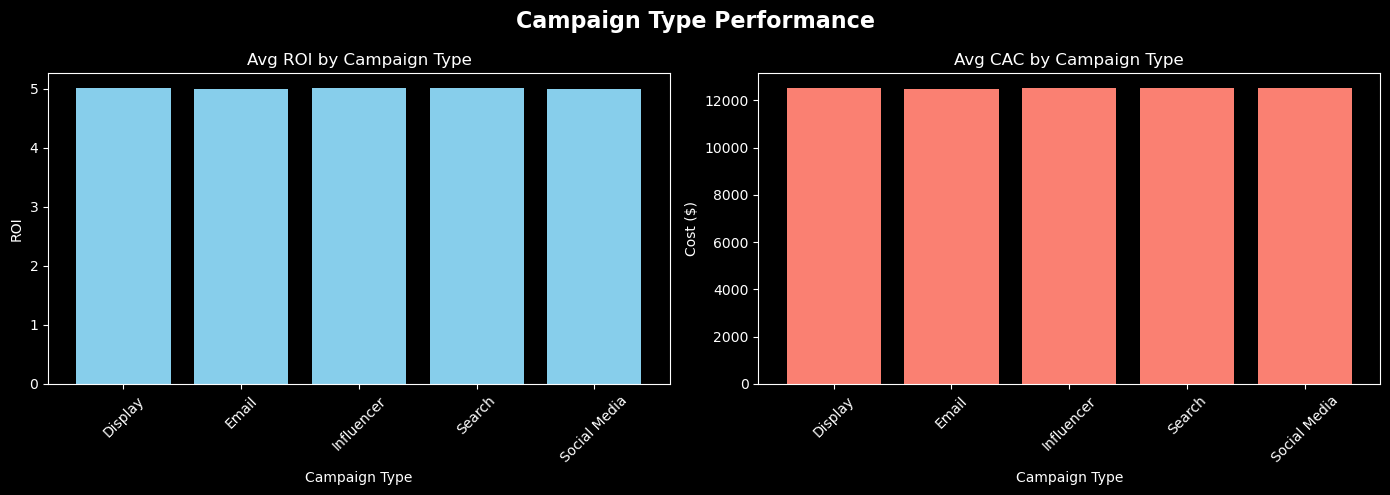

In [22]:
campaign_performance = df.groupby('Campaign_Type').agg(
    Avg_ROI        = ('ROI', 'mean'),
    Avg_CTR        = ('CTR', 'mean'),
    Avg_Conversion = ('Conversion_Rate', 'mean'),
    Avg_CAC        = ('Acquisition_Cost', 'mean'),
    Campaign_Count = ('Campaign_ID', 'count')
).round(2).reset_index()

print(campaign_performance)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Campaign Type Performance', fontsize=16, fontweight='bold')

axes[0].bar(campaign_performance['Campaign_Type'], 
            campaign_performance['Avg_ROI'], 
            color='skyblue')
axes[0].set_title('Avg ROI by Campaign Type')
axes[0].set_xlabel('Campaign Type')
axes[0].set_ylabel('ROI')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(campaign_performance['Campaign_Type'], 
            campaign_performance['Avg_CAC'], 
            color='salmon')
axes[1].set_title('Avg CAC by Campaign Type')
axes[1].set_xlabel('Campaign Type')
axes[1].set_ylabel('Cost ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('campaign_type_performance.png', dpi=150, bbox_inches='tight')
plt.show()

  Target_Audience  Avg_ROI  Avg_Conversion   Avg_CAC  Campaign_Count
2       Men 25-34     5.02            0.08  12480.62           40023
0        All Ages     5.01            0.08  12501.91           40019
4     Women 35-44     5.01            0.08  12515.62           39687
3     Women 25-34     5.00            0.08  12500.49           40013
1       Men 18-24     4.98            0.08  12523.30           40258


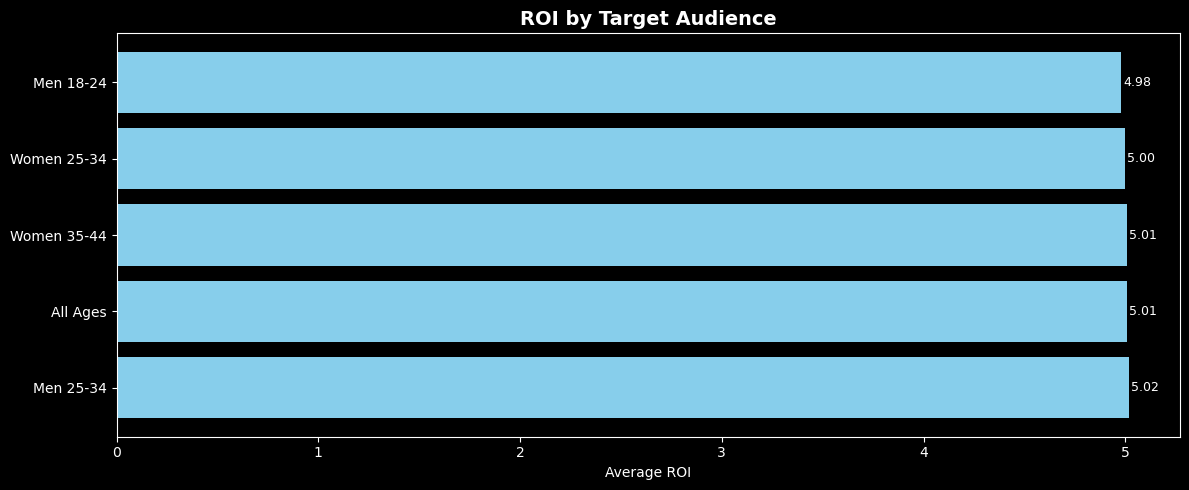

In [24]:
# Section 3 — Target Audience Analysis
audience_performance = df.groupby('Target_Audience').agg(
    Avg_ROI        = ('ROI', 'mean'),
    Avg_Conversion = ('Conversion_Rate', 'mean'),
    Avg_CAC        = ('Acquisition_Cost', 'mean'),
    Campaign_Count = ('Campaign_ID', 'count')
).round(2).reset_index().sort_values('Avg_ROI', ascending=False)

print(audience_performance.to_string())

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(audience_performance['Target_Audience'], 
               audience_performance['Avg_ROI'],
               color='skyblue')
ax.set_title('ROI by Target Audience', fontsize=14, fontweight='bold')
ax.set_xlabel('Average ROI')
# Add value labels on bars
for bar, val in zip(bars, audience_performance['Avg_ROI']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('audience_performance.png', dpi=150, bbox_inches='tight')
plt.show()

      Location  Avg_ROI   Avg_CAC  Campaign_Count
1      Houston     5.01  12454.39           39750
2  Los Angeles     5.01  12532.54           39947
3        Miami     5.01  12515.21           40269
0      Chicago     5.00  12515.16           40010
4     New York     4.98  12504.32           40024


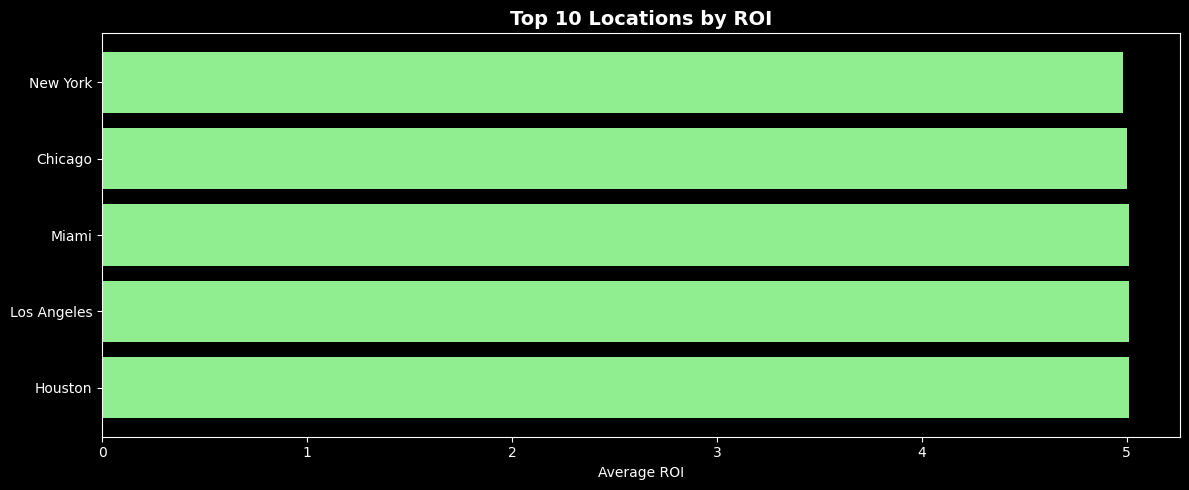

In [25]:
# Section 4 — Location Analysis (Top 10 cities)
location_performance = df.groupby('Location').agg(
    Avg_ROI        = ('ROI', 'mean'),
    Avg_CAC        = ('Acquisition_Cost', 'mean'),
    Campaign_Count = ('Campaign_ID', 'count')
).round(2).reset_index().sort_values('Avg_ROI', ascending=False).head(10)

print(location_performance.to_string())

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(location_performance['Location'],
        location_performance['Avg_ROI'],
        color='lightgreen')
ax.set_title('Top 10 Locations by ROI', fontsize=14, fontweight='bold')
ax.set_xlabel('Average ROI')
plt.tight_layout()
plt.savefig('location_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Section 5 — Time Series Analysis
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

monthly_performance = df.groupby('Month').agg(
    Avg_ROI        = ('ROI', 'mean'),
    Avg_CTR        = ('CTR', 'mean'),
    Avg_Conversion = ('Conversion_Rate', 'mean'),
    Total_Campaigns = ('Campaign_ID', 'count')
).reset_index()

monthly_performance['Month_str'] = monthly_performance['Month'].astype(str)

print(monthly_performance.to_string())

      Month   Avg_ROI    Avg_CTR  Avg_Conversion  Total_Campaigns Month_str
0   2021-01  5.014595  14.152063        0.080084            16988   2021-01
1   2021-02  5.005248  14.081157        0.080181            15344   2021-02
2   2021-03  4.983404  14.020457        0.080032            16988   2021-03
3   2021-04  4.994372  13.983970        0.080460            16440   2021-04
4   2021-05  5.018923  14.153381        0.079781            16988   2021-05
5   2021-06  4.985203  13.832879        0.080078            16440   2021-06
6   2021-07  4.983045  14.175578        0.079952            16988   2021-07
7   2021-08  4.997793  13.944312        0.079725            16988   2021-08
8   2021-09  5.029044  14.001017        0.080243            16440   2021-09
9   2021-10  5.016445  14.180609        0.079819            16988   2021-10
10  2021-11  4.999271  13.957534        0.080301            16440   2021-11
11  2021-12  5.002122  13.995035        0.080216            16968   2021-12


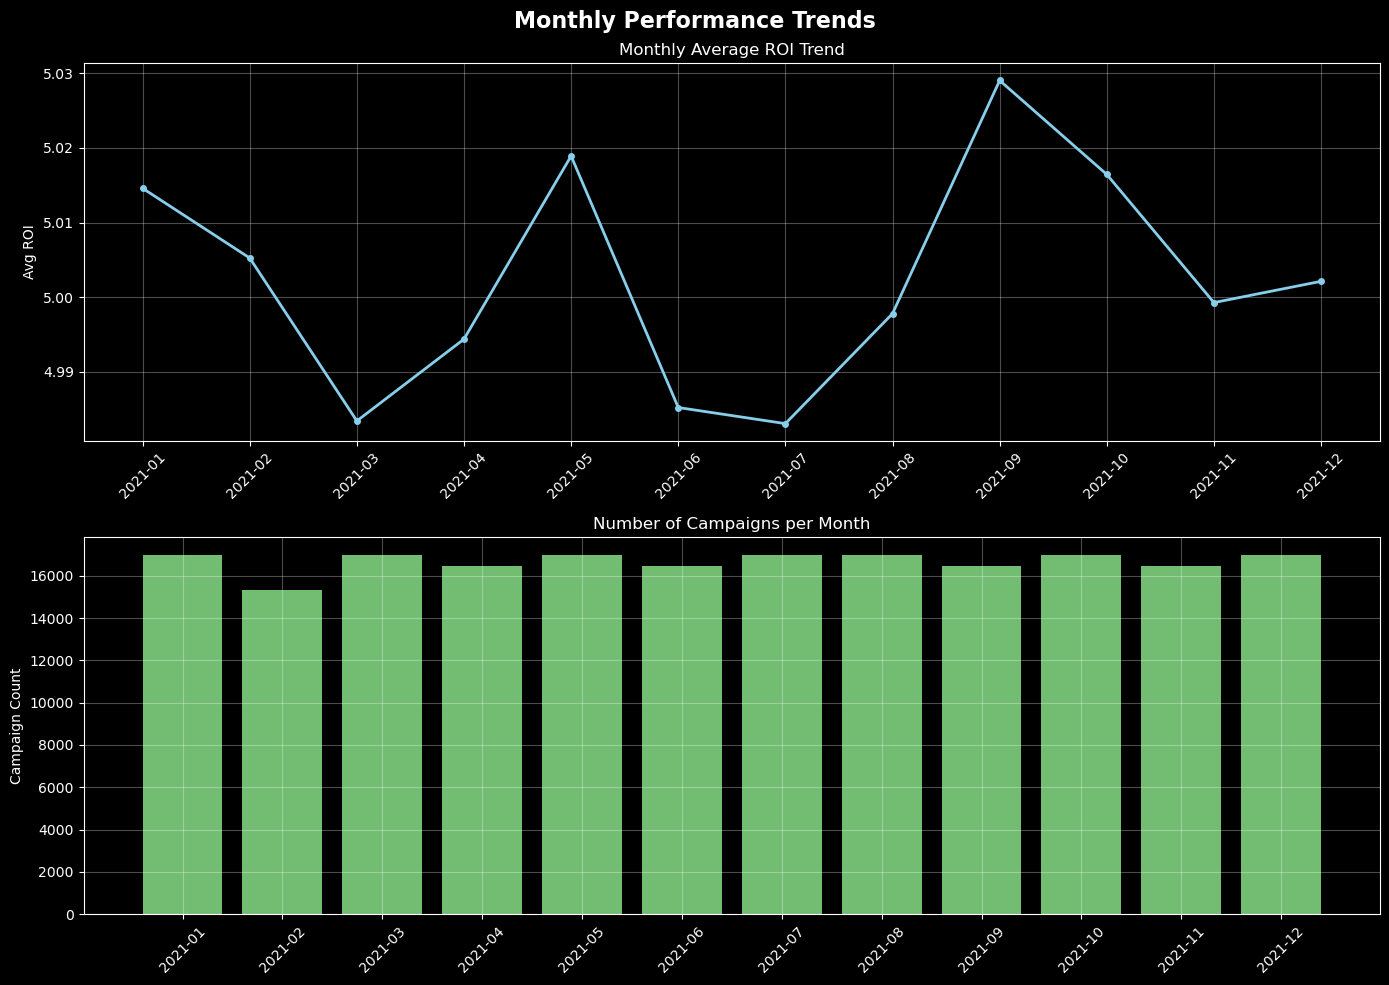

In [27]:
# Plot time series
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Monthly Performance Trends', fontsize=16, fontweight='bold')

# ROI over time
axes[0].plot(monthly_performance['Month_str'], 
             monthly_performance['Avg_ROI'],
             color='skyblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Monthly Average ROI Trend')
axes[0].set_ylabel('Avg ROI')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Campaign count over time
axes[1].bar(monthly_performance['Month_str'],
            monthly_performance['Total_Campaigns'],
            color='lightgreen', alpha=0.8)
axes[1].set_title('Number of Campaigns per Month')
axes[1].set_ylabel('Campaign Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_series.png', dpi=150, bbox_inches='tight')
plt.show()

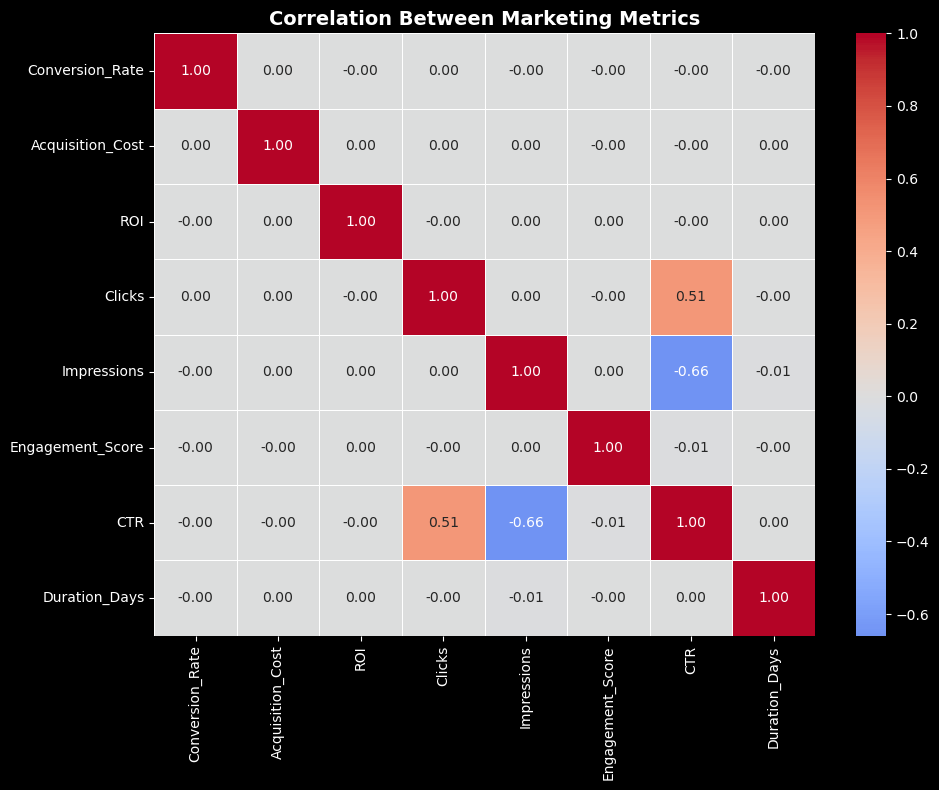

In [28]:
# Section 6 — Correlation Heatmap
# Shows which metrics are related to each other

numeric_cols = ['Conversion_Rate', 'Acquisition_Cost', 
                'ROI', 'Clicks', 'Impressions', 
                'Engagement_Score', 'CTR', 'Duration_Days']

correlation_matrix = df[numeric_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,           # show numbers
            cmap='coolwarm',      # red-blue color scheme
            center=0,             # center at 0
            fmt='.2f',
            linewidths=0.5)
plt.title('Correlation Between Marketing Metrics', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

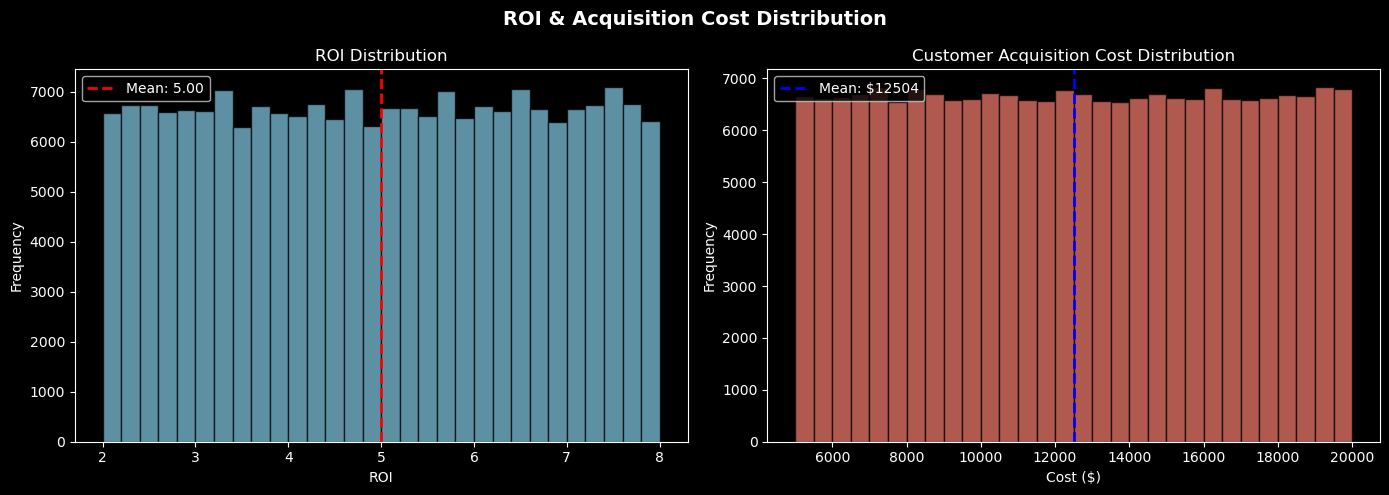

In [29]:
# Section 7 — ROI Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROI & Acquisition Cost Distribution', fontsize=14, fontweight='bold')

# ROI histogram
axes[0].hist(df['ROI'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['ROI'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f"Mean: {df['ROI'].mean():.2f}")
axes[0].set_title('ROI Distribution')
axes[0].set_xlabel('ROI')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# CAC histogram
axes[1].hist(df['Acquisition_Cost'], bins=30, color='salmon', 
             edgecolor='black', alpha=0.7)
axes[1].axvline(df['Acquisition_Cost'].mean(), color='blue', linestyle='--',
                linewidth=2, label=f"Mean: ${df['Acquisition_Cost'].mean():.0f}")
axes[1].set_title('Customer Acquisition Cost Distribution')
axes[1].set_xlabel('Cost ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
    # Section 8 — Complete Business Insights Summary
print("=" * 60)
print("   MARKETING CAMPAIGN PERFORMANCE — EXECUTIVE SUMMARY")
print("=" * 60)

print(f"\n📊 DATASET OVERVIEW")
print(f"   Total Campaigns Analyzed : {len(df):,}")
print(f"   Date Range               : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"   Channels Covered         : {df['Channel_Used'].nunique()}")
print(f"   Cities Covered           : {df['Location'].nunique()}")

print(f"\n💰 KEY PERFORMANCE METRICS")
print(f"   Average ROI              : {df['ROI'].mean():.2f}x")
print(f"   Average CAC              : ${df['Acquisition_Cost'].mean():,.0f}")
print(f"   Average CTR              : {df['CTR'].mean():.2f}%")
print(f"   Average Conversion Rate  : {df['Conversion_Rate'].mean()*100:.2f}%")

print(f"\n🏆 TOP PERFORMERS")
best_channel = channel_performance.loc[channel_performance['Avg_ROI'].idxmax(), 'Channel_Used']
worst_channel = channel_performance.loc[channel_performance['Avg_ROI'].idxmin(), 'Channel_Used']
best_audience = audience_performance.iloc[0]['Target_Audience']
best_city = location_performance.iloc[0]['Location']
best_month = monthly_performance.loc[monthly_performance['Avg_ROI'].idxmax(), 'Month_str']

print(f"   Best Channel             : {best_channel}")
print(f"   Worst Channel            : {worst_channel}")
print(f"   Best Audience Segment    : {best_audience}")
print(f"   Best Performing City     : {best_city}")
print(f"   Peak Performance Month   : {best_month}")

print(f"\n📋 RECOMMENDATIONS")
print(f"   1. Increase budget allocation to {best_channel} campaigns")
print(f"   2. Focus targeting on {best_audience} demographic")
print(f"   3. Prioritize campaigns in {best_city} for best ROI")
print(f"   4. Scale up campaigns in {best_month} — historically peak month")
print(f"   5. High impressions hurt CTR — use targeted over broad reach")
print("=" * 60)

   MARKETING CAMPAIGN PERFORMANCE — EXECUTIVE SUMMARY

📊 DATASET OVERVIEW
   Total Campaigns Analyzed : 200,000
   Date Range               : 2021-01-01 to 2021-12-31
   Channels Covered         : 6
   Cities Covered           : 5

💰 KEY PERFORMANCE METRICS
   Average ROI              : 5.00x
   Average CAC              : $12,504
   Average CTR              : 14.04%
   Average Conversion Rate  : 8.01%

🏆 TOP PERFORMERS
   Best Channel             : Facebook
   Worst Channel            : Instagram
   Best Audience Segment    : Men 25-34
   Best Performing City     : Houston
   Peak Performance Month   : 2021-09

📋 RECOMMENDATIONS
   1. Increase budget allocation to Facebook campaigns
   2. Focus targeting on Men 25-34 demographic
   3. Prioritize campaigns in Houston for best ROI
   4. Scale up campaigns in 2021-09 — historically peak month
   5. High impressions hurt CTR — use targeted over broad reach
